# Creating an Image Classification Dataset based on MultiCaRe Subsets

First of all, install the `multiversity` library, import the MedicalDatasetCreator class, and instantiate it.

In [1]:
%%capture
!pip install multiversity

In [2]:
from multiversity.multicare_dataset import MedicalDatasetCreator

In [3]:
mdc = MedicalDatasetCreator(directory = 'medical_datasets')

The MultiCaRe Dataset is already downloaded.
Importing and pre-processing the main files.
Done!


In [4]:
skin_photographs_filter = [
    {'field': 'label', 'string_list': ['skin_photograph'], 'operator': 'any'},
    {'field': 'label', 'string_list': ['chart'], 'operator': 'none'}
]

In [5]:
mdc.create_dataset(dataset_name='skin_photographs', filter_list=skin_photographs_filter, dataset_type='multimodal')

The skin_photographs was successfully created!


This code extracts cases matching the 7 common tropical and infectious diseases in Vietnam:

In [51]:
disease_terms = {
    'hfmd': ['hand foot and mouth disease', 'hand-foot-mouth', 'HFMD'],
    'dengue': ['dengue'],
    'scrub_typhus': ['scrub typhus'],
    'leprosy': ['leprosy', "hansen's disease", 'hansen disease'],
    'melioidosis': ['melioidosis'],
    'chikungunya': ['chikungunya'],
    'measles': ['measles', 'rubeola']
}

for name, terms in disease_terms.items():
    f = [{'field': 'case_strings', 'string_list': terms, 'operator': 'any'},
         {'field': 'label', 'string_list': ['skin_photograph'], 'operator': 'any'}]
    mdc.create_dataset(dataset_name=f'_tmp_{name}', filter_list=f, dataset_type='image')

The _tmp_hfmd was successfully created!
The _tmp_dengue was successfully created!
The _tmp_scrub_typhus was successfully created!
The _tmp_leprosy was successfully created!
The _tmp_melioidosis was successfully created!
The _tmp_chikungunya was successfully created!
The _tmp_measles was successfully created!


This code will create an image classification dataset by creating multiple subsets and then assigning one class to each. If all the subsets belong to a specific type of image, a common filter list can be added to the `dataset_dict` param. To understand how to use filters correctly, refer to [this demo](https://github.com/mauro-nievoff/MultiCaRe_Dataset/blob/main/Demos/customized_subset_creation.ipynb).

**Case PMC1334206_01:**

'Gender: Male'

'Age: 7.0'

'Clinical Case:'

"This twenty-seven years old male presented with complaints of fever with rigor and chills and sore throat for ten days. It was associated with myalgia and recurrent vomiting followed by diffuse maculopapular rash all over the body with sparing of mucous membranes and periorbital tissues. On examination, he had conjunctival congestion with toxic facies. He had a past history of gout for which he received allolpurinol for twenty days and phenytoin for sudden loss of consciousness in another institution. There was no past history of tuberculosis, diabetes or hypertension.\nBilateral hard indurated cervical lymphadenopathy and bilateral inguinal lymphadenopathy was also observed along with bilateral parotid and submandibular gland enlargement. Hepatosplenomegaly was detected on ultrasonography. Hemogram on several occasions from admission revealed normal hemoglobin and red blood cell morphology. There was transient neutrophilic leukocytosis, whereas platelet counts and erythrocyte sedimen

**Image:**

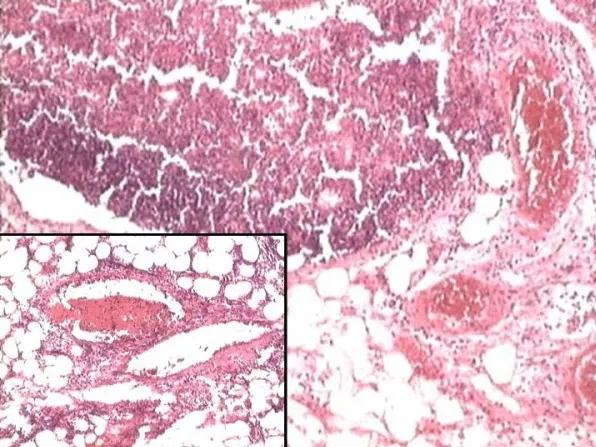

**Image Labels:**

['pathology', 'h&e', 'pathology', 'h&e']

**Image Caption:**

Perinodal blood vessels show marked congestion (H&E-40X), and fibrin thrombi (Inset-H&E-100X).

**Citation Information:**

{'pmcid': 'PMC1334206',
 'doi': '10.1186/1472-6890-5-11',
 'pmid': '16336698',
 'title': 'Lymph node infarction--a rare complication associated with disseminated intra vascular coagulation in a case of dengue fever',
 'year': '2005',
 'authors': ['I Satish Rao', 'Anand C Loya', 'K S Ratnakar', 'V R Srinivasan'],
 'journal': 'BMC Clin Pathol',
 'journal_detail': '2005 Dec 12;5:11.',
 'link': 'https://pubmed.ncbi.nlm.nih.gov/16336698/',
 'license': 'CC BY'}

In [45]:
mdc.display_example(1)

In [9]:
classifier_dict = {
    'dataset_name': 'gender_classifier',
    'common_filter_list': mri_filters,
    'class_subsets': [
        {'class': 'female',
         'filter_list': [{'field': 'gender', 'string_list': ['Female']}]},
        {'class': 'male',
         'filter_list': [{'field': 'gender', 'string_list': ['Male']}]}
    ]
}


In [10]:
mdc.create_image_classification_dataset(dataset_dict = classifier_dict,
                                        keep_label_columns = False) # Use True if you want to keep also the label columns from the original dataset ('image_type', etc).

The gender_classifier_female was successfully created!
The gender_classifier_male was successfully created!


In [11]:
import pandas as pd

classification_dataset = pd.read_csv('medical_datasets/gender_classifier/gender_classifier.csv')

As an outcome you will get a dataframe including the path to each image and its class.

In [12]:
classification_dataset.head()

,file_id,file,file_path,class
0,file_0006439,PMC10295819_encephalitis-2022-00122f1_A_1_6.webp,medical_datasets/gender_classifier_female/imag...,female
1,file_0006440,PMC10295819_encephalitis-2022-00122f1_B_2_6.webp,medical_datasets/gender_classifier_female/imag...,female
2,file_0006441,PMC10295819_encephalitis-2022-00122f1_C_3_6.webp,medical_datasets/gender_classifier_female/imag...,female
3,file_0006442,PMC10295819_encephalitis-2022-00122f1_D_4_6.webp,medical_datasets/gender_classifier_female/imag...,female
4,file_0006443,PMC10295819_encephalitis-2022-00122f1_E_5_6.webp,medical_datasets/gender_classifier_female/imag...,female
